In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [ ]:
#Start and End Date
start_date = "2024-01-01"
end_date = "2025-09-30"

#Equities
Equity_Names = [
    "NVDA", "MSFT", "AAPL", "GOOG", "GOOGL", "AMZN", "META", "AVGO", "TSM", "TSLA",
     "JPM", "ORCL", "WMT", "TCEHY", "LLY", "V", "MA", "NFLX",
    "XOM", "PLTR", "BABA", "JNJ", "COST", "HD", "ABBV", "BAC", "ASML", "PG",
    "IDCBY", "SAP", "CVX", "GE", "UNH", "ACGBY", "TM", "KO", "WFC", "RHHBY",
    "TMUS", "CSCO", "AMD", "NVS", "NVO", "MS", "CICHY", "PM", "IBM", "GS",
    "HSBC", "ABT", "AXP", "AZN", "CRM", "SIEGY", "SHEL", "RY", "DIS", "UBER",
    "T", "BACHY", "MRK", "PEP", "NOW", "INTU", "SHOP", "MUFG", "XIACY", "QCOM",
    "C", "BLK", "SFTBY", "VZ", "PDD", "MU", "SONY", "CMWAY", "ANET", "BKNG",
    "TMO", "HDB", "GEV", "TXN", "SCHW", "DTEGY", "BA", "PROSY", "LRCX", "AMAT",
    "ISRG", "ALIZY", "TJX", "ARM", "NEE", "AMGN", "APH", "ADBE", "SPGI", "ACN",
    "BYDDY"
]

#Equity_Names = ["NVDA","MSFT"]

#Get the daily Close prices of Universe Equities from start to end

price_data = yf.download(Equity_Names,interval="1h",start=start_date,end=end_date)
price_data = price_data['Close']

#Get the daily returns on the close prices

returns_data = price_data.pct_change(periods=7)[7:]
returns_data = returns_data[::7]

/tmp/ipython-input-2702087297.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data = yf.download(Equity_Names,interval="1h",start=start_date,end=end_date)
[*********************100%***********************]  99 of 99 completed
/tmp/ipython-input-2702087297.py:29: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_data = price_data.pct_change(periods=7)[7:]


In [ ]:
returns_data = returns_data.fillna(-1)
print(price_data)
print(returns_data)

Ticker                           AAPL        ABBV         ABT    ACGBY  \
Datetime                                                                 
2024-01-02 14:30:00+00:00  186.189896  158.970001  110.650002   9.2436   
2024-01-02 15:30:00+00:00  186.804993  158.699997  110.419998      NaN   
2024-01-02 16:30:00+00:00  186.615005  159.115005  110.580002   9.4450   
2024-01-02 17:30:00+00:00  185.294998  159.649994  110.525002   9.4450   
2024-01-02 18:30:00+00:00  184.494995  159.744995  110.269997   9.4450   
...                               ...         ...         ...      ...   
2025-09-29 15:30:00+00:00  253.660004  221.309998  132.830002      NaN   
2025-09-29 16:30:00+00:00  253.399994  220.332596  132.487503      NaN   
2025-09-29 17:30:00+00:00  254.570007  221.490005  132.600006      NaN   
2025-09-29 18:30:00+00:00  253.990005  222.005005  132.899994  16.8400   
2025-09-29 19:30:00+00:00  254.350006  223.190002  133.110001      NaN   

Ticker                            ACN

In [ ]:
date_column = price_data.index
date_column_formatted = []
for x in range(0,len(date_column)):
  date_to_format = str(date_column[x])
  date_column_formatted.append(date_to_format[:10])
  #print(price_data.index[x])
  #print(date_column_formatted[x])
price_data['DayDate'] = date_column_formatted

date_column = returns_data.index
date_column_formatted = []
for x in range(0,len(date_column)):
  date_to_format = str(date_column[x])
  date_column_formatted.append(date_to_format[:10])
  #print(price_data.index[x])
  #print(date_column_formatted[x])
returns_data['DayDate'] = date_column_formatted

print(returns_data)


Ticker                         AAPL      ABBV       ABT     ACGBY       ACN  \
Datetime                                                                      
2024-01-03 14:30:00+00:00 -0.011983  0.016104 -0.008857  0.038016 -0.016096   
2024-01-04 14:30:00+00:00 -0.012387 -0.002476  0.009529  0.005732 -0.005550   
2024-01-05 14:30:00+00:00  0.002147  0.008068 -0.001581  0.000000 -0.004303   
2024-01-08 14:30:00+00:00  0.009557 -0.010589  0.006785 -0.010466  0.000687   
2024-01-09 14:30:00+00:00 -0.001551  0.013690  0.016893  0.002199  0.006117   
...                             ...       ...       ...       ...       ...   
2025-09-23 18:30:00+00:00 -0.006334 -0.005541 -0.010355 -0.000597 -0.021096   
2025-09-24 18:30:00+00:00 -0.010937 -0.013076 -0.013042 -0.004782  0.017778   
2025-09-25 18:30:00+00:00  0.022157 -0.004712 -0.003621 -0.017417 -0.031123   
2025-09-26 18:30:00+00:00 -0.005117  0.006153  0.001798  0.001222  0.041202   
2025-09-29 18:30:00+00:00 -0.006474  0.009389 -0.005

2024-01-03 14:30:00+00:00
2024-01-03 14:30:00+00:00
PDD :  149.3300018310547
298.6600036621094
147.83670181274414
Days Prices:
Datetime
2024-01-03 14:30:00+00:00    149.330002
2024-01-03 15:30:00+00:00    148.830002
2024-01-03 16:30:00+00:00    148.839996
2024-01-03 17:30:00+00:00    148.740005
2024-01-03 18:30:00+00:00    148.979996
2024-01-03 19:30:00+00:00    148.934998
2024-01-03 20:30:00+00:00    148.960007
Name: PDD, dtype: float64
NO SL/TP ACTIVATED
0.9975222988505277
2024-01-04 14:30:00+00:00
LLY :  633.5499877929688
1267.0999755859375
627.2144879150391
Days Prices:
Datetime
2024-01-04 14:30:00+00:00    633.549988
2024-01-04 15:30:00+00:00    629.969971
2024-01-04 16:30:00+00:00    627.908020
2024-01-04 17:30:00+00:00    621.830017
2024-01-04 18:30:00+00:00    620.134583
2024-01-04 19:30:00+00:00    617.169983
2024-01-04 20:30:00+00:00    614.719971
Name: LLY, dtype: float64
SL ACTIVATED
0.9875470758620224
2024-01-05 14:30:00+00:00
SHOP :  75.55500030517578
151.11000061035156
7

/tmp/ipython-input-3266575535.py:56: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  returns.append((1+((daysPrices[6] - daysPrices[0])/daysPrices[0])) * returns[x-1])


Streaming output truncated to the last 5000 lines.
2024-06-18 15:30:00+00:00    154.229996
2024-06-18 16:30:00+00:00    153.070007
2024-06-18 17:30:00+00:00    153.750107
2024-06-18 18:30:00+00:00    153.020004
2024-06-18 19:30:00+00:00    153.470001
Name: MU, dtype: float64
SL ACTIVATED
1.3970986848083482
2024-06-20 13:30:00+00:00
GEV :  182.5592041015625
365.118408203125
180.73361206054688
Days Prices:
Datetime
2024-06-20 13:30:00+00:00    182.559204
2024-06-20 14:30:00+00:00    183.740005
2024-06-20 15:30:00+00:00    180.190002
2024-06-20 16:30:00+00:00    176.929993
2024-06-20 17:30:00+00:00    179.679993
2024-06-20 18:30:00+00:00    178.059998
2024-06-20 19:30:00+00:00    177.220001
Name: GEV, dtype: float64
SL ACTIVATED
1.3831276979602647
2024-06-21 13:30:00+00:00
IDCBY :  nan
nan
nan
Days Prices:
Datetime
2024-06-21 14:30:00+00:00    11.53
2024-06-21 15:30:00+00:00    11.50
2024-06-21 18:30:00+00:00    11.46
2024-06-24 13:30:00+00:00    11.70
2024-06-24 14:30:00+00:00    11.69
2

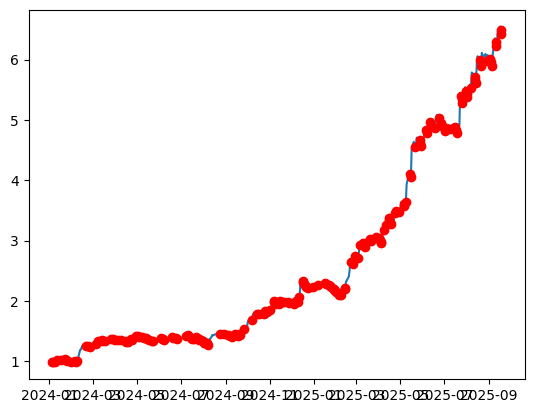

In [ ]:
returns = [1]
daysTraded = []
labels = []
tpPercent = 2
slPercent = 0.99
print(returns_data.index[0])
for x in range(1,len(returns_data)-6):
  previous_days_return = returns_data.loc[returns_data.index[x-1]]
  previous_days_return = previous_days_return[:-1]
  previous_days_return_sorted = previous_days_return.sort_values(ascending=False)
  buy_stock = previous_days_return_sorted.index[0]
  currentDateTime = previous_days_return_sorted.name
  buyPrice = price_data.loc[pd.Timestamp(currentDateTime), buy_stock]
  tp = tpPercent * buyPrice
  sl = slPercent * buyPrice
  start_loc = price_data.index.get_loc(pd.Timestamp(currentDateTime))
  daysPrices = (
    price_data.iloc[start_loc:, price_data.columns.get_loc(buy_stock)]
    .dropna()
    .iloc[:7]
)

  first_below_sl = daysPrices[daysPrices < sl].index[0] if (daysPrices < sl).any() else False

  first_above_tp = daysPrices[daysPrices > tp].index[0] if (daysPrices > tp).any() else False
  print(currentDateTime)
  print(buy_stock,": ",buyPrice)
  print(tpPercent*buyPrice)
  print(slPercent*buyPrice)
  print("Days Prices:")
  print(daysPrices)
  if first_above_tp != False:
    if first_below_sl == False:
      returns.append(tpPercent*returns[x-1])
      print('TP ACTIVATED')
      labels.append("green")

    elif first_above_tp < first_below_sl:
        returns.append(tpPercent*returns[x-1])
        print('TP ACTIVATED')
        labels.append("green")

  if first_below_sl != False:
    if first_above_tp == False:
      returns.append(slPercent*returns[x-1])
      print('SL ACTIVATED')
      labels.append("red")
    elif first_above_tp > first_below_sl:
        returns.append(slPercent*returns[x-1])
        print('SL ACTIVATED')
        labels.append("red")


  if first_above_tp == False:
    if first_below_sl == False:
      returns.append((1+((daysPrices[6] - daysPrices[0])/daysPrices[0])) * returns[x-1])
      labels.append("")
      print("NO SL/TP ACTIVATED")

  daysTraded.append(currentDateTime)

  print(returns[x])
  #if daysPrices.isna().sum() > 0:
    #print(daysPrices)
    #print('Day Prices have NaN')

returns = returns[1:]
daysTraded = np.array(daysTraded)
returns = np.array(returns)
labels = np.array(labels, dtype=object)
plt.scatter(daysTraded[labels == "green"], returns[labels == "green"], color='green', label='Green points', zorder=3)
plt.scatter(daysTraded[labels == "red"], returns[labels == "red"], color='red', label='Red points', zorder=3)

plt.plot(daysTraded,returns)



In [ ]:
print(daysTraded)
print(returns)
print(labels)

[Timestamp('2025-01-03 14:30:00+0000', tz='UTC')
 Timestamp('2025-01-06 14:30:00+0000', tz='UTC')
 Timestamp('2025-01-07 14:30:00+0000', tz='UTC')
 Timestamp('2025-01-08 14:30:00+0000', tz='UTC')
 Timestamp('2025-01-10 14:30:00+0000', tz='UTC')
 Timestamp('2025-01-13 14:30:00+0000', tz='UTC')
 Timestamp('2025-01-14 14:30:00+0000', tz='UTC')
 Timestamp('2025-01-15 14:30:00+0000', tz='UTC')
 Timestamp('2025-01-16 14:30:00+0000', tz='UTC')
 Timestamp('2025-01-17 14:30:00+0000', tz='UTC')
 Timestamp('2025-01-21 14:30:00+0000', tz='UTC')]
[1.00727118 1.02238024 1.00193264 0.98189399 0.9966224  0.99313766
 0.9834174  0.98044932 0.96413277 0.97270161 0.978566  ]
['' 'green' 'red' 'red' 'green' '' '' '' '' '' '']
